In [1]:
pip install opendatasets

In [2]:
import opendatasets as od
import zipfile
import os
import numpy as np
import pandas as pd

# Specify the Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/datasets/adityagaikwad9552/ucf-crime-splitted-i3d-features'

# Download the dataset (will download as a zip file by default)
od.download(dataset_url)

Dataset URL: https://www.kaggle.com/datasets/adityagaikwad9552/ucf-crime-splitted-i3d-features


100%|██████████| 2.48G/2.48G [00:30<00:00, 88.1MB/s]


#1. Data Loading and Preparation

 1.1 Import Libraries and Define Data Paths

In [3]:
# cell 1
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from tensorflow.keras.models import load_model
import random
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc


Dataset = '/content/ucf-crime-splitted-i3d-features'

def print_detailed_video_sequence_stats(base_dir):
    for split in ['train', 'val', 'test']:
        print(f"\n {split.upper()} SET:")
        split_dir = os.path.join(base_dir, split)

        total_videos = 0
        total_sequences = 0

        for label in ['normal', 'anomaly']:
            label_path = os.path.join(split_dir, label)
            label_video_count = 0
            label_seq_count = 0

            for video in os.listdir(label_path):
                video_path = os.path.join(label_path, video)
                if os.path.isdir(video_path):
                    label_video_count += 1
                    label_seq_count += len([
                        f for f in os.listdir(video_path) if f.endswith('.npz')
                    ])

            total_videos += label_video_count
            total_sequences += label_seq_count

            print(f"   {label.capitalize():<8}: {label_video_count:>4} videos, {label_seq_count:>5} sequences")

        print(f"   TOTAL     : {total_videos:>4} videos, {total_sequences:>5} sequences")

# Usage:
print_detailed_video_sequence_stats(Dataset)




 TRAIN SET:
   Normal  :  665 videos, 39286 sequences
   Anomaly :  665 videos, 34223 sequences
   TOTAL     : 1330 videos, 73509 sequences

 VAL SET:
   Normal  :  142 videos,  8382 sequences
   Anomaly :  143 videos,  7965 sequences
   TOTAL     :  285 videos, 16347 sequences

 TEST SET:
   Normal  :  143 videos,  9071 sequences
   Anomaly :  142 videos,  7632 sequences
   TOTAL     :  285 videos, 16703 sequences


1.2 Load Sequence-Level Data

In [4]:

def load_split_sequences(base_dir):
    X, y = [], []
    for label in ['normal', 'anomaly']:
        label_path = os.path.join(base_dir, label)
        label_value = 0 if label == 'normal' else 1
        for video in tqdm(os.listdir(label_path), desc=f"Loading {label}"):
            video_path = os.path.join(label_path, video)
            for file in sorted(os.listdir(video_path)):
                if file.endswith('.npz'):
                    arr = np.load(os.path.join(video_path, file))['feature_array']
                    X.append(arr)
                    y.append(label_value)
    return np.array(X), np.array(y)

X_train, y_train = load_split_sequences(os.path.join(Dataset, 'train'))
X_val, y_val = load_split_sequences(os.path.join(Dataset, 'val'))
X_test, y_test = load_split_sequences(os.path.join(Dataset, 'test'))



Loading anomaly: 100%|██████████| 142/142 [00:05<00:00, 25.55it/s]


1.3 Load Video-Level Data and Define Evaluation Function

In [5]:
def load_videos_with_sequences(split_dir):
    """
    Loads all videos in split_dir (should have normal/ & anomaly/)
    Returns list of dicts: [{ 'label': 0/1, 'sequences': np.array(...), 'video_name': '...' }, ...]
    """
    video_data = []
    LABEL_MAP = {'normal': 0, 'anomaly': 1}

    for label in ['normal', 'anomaly']:
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for video_name in tqdm(os.listdir(label_dir), desc=f"Loading {label} videos", unit="video"):
            video_path = os.path.join(label_dir, video_name)
            if not os.path.isdir(video_path):
                continue
            sequences = []
            for file in sorted(os.listdir(video_path)):
                if file.endswith('.npz'):
                    try:
                        arr = np.load(os.path.join(video_path, file))['feature_array']
                        sequences.append(arr)
                    except Exception as e:
                        print(f"Error loading {file} from {video_name}: {e}")
                        continue
            if sequences:
                video_data.append({
                    'label': LABEL_MAP[label],
                    'sequences': np.array(sequences),
                    'video_name': video_name
                })
    return video_data


def evaluate_video_level(split_name, model, videos, top_k=2):
    """Evaluate model on video level using average of top-k sequence probabilities."""
    y_true, y_pred, y_prob = [], [], []

    for vid in tqdm(videos, desc=f"Evaluating {split_name}", unit="video"):
        seq_preds = model.predict(vid["sequences"], verbose=0).flatten()
        if seq_preds.size == 0:
            continue  # skip empty videos just in case

        # take average of top-k sequence predictions
        top_k_preds = np.sort(seq_preds)[-top_k:]   # pick top k scores
        video_score = np.mean(top_k_preds)

        video_pred = int(video_score >= 0.5)

        y_true.append(vid["label"])
        y_pred.append(video_pred)
        y_prob.append(video_score)

    roc = roc_auc_score(y_true, y_prob)

    print(f"\n📊 Video-Level Evaluation (Top-{top_k} Avg): {split_name}")
    print(f"ROC AUC       : {roc:.4f}")

    return y_true, y_prob


#2. Multiple Model Training

2.1 mean model

In [ ]:
# mean moodel
def get_model_mean(input_shape=(7, 1, 1, 1024)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Reshape((7, 1024))(inputs)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, x)

model = get_model_mean()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
checkpoint = tf.keras.callbacks.ModelCheckpoint("mean.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1)

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=32, callbacks=[checkpoint], verbose=1)



Epoch 1/15
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - auc: 0.8849 - loss: 0.4164
Epoch 1: val_auc improved from -inf to 0.85830, saving model to mean.keras
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8063 - auc: 0.8849 - loss: 0.4164 - val_accuracy: 0.7777 - val_auc: 0.8583 - val_loss: 0.5348
Epoch 2/15
2280/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9248 - auc: 0.9770 - loss: 0.1960
Epoch 2: val_auc improved from 0.85830 to 0.87993, saving model to mean.keras
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9249 - auc: 0.9771 - loss: 0.1959 - val_accuracy: 0.8052 - val_auc: 0.8799 - val_loss: 0.5162
Epoch 3/15
2293/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9527 - auc: 0.9900 - loss: 0.1279
Epoch 3: val_auc did not improve from 0.87993
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9527 - auc: 0.9900 - loss: 0.1279 - val_accuracy: 0.7985 - val_auc: 0.8786 - val_loss: 0.5456
Epoch 4/15
2285/2298 ━━━━━━━━━━━━━━━━━━━

2.2 max model

In [ ]:
# cell 6
def get_model_max(input_shape=(7, 1, 1, 1024)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Reshape((7, 1024))(inputs)
    x = layers.GlobalMaxPooling1D()(x)
    # x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, x)

model = get_model_max()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
checkpoint = tf.keras.callbacks.ModelCheckpoint("max.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1)
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=128, callbacks=[checkpoint], verbose=1)

Epoch 1/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7701 - auc: 0.8476 - loss: 0.4682
Epoch 1: val_auc improved from -inf to 0.86301, saving model to max.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7702 - auc: 0.8477 - loss: 0.4680 - val_accuracy: 0.7879 - val_auc: 0.8630 - val_loss: 0.5070
Epoch 2/15
568/575 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8882 - auc: 0.9557 - loss: 0.2694
Epoch 2: val_auc improved from 0.86301 to 0.87929, saving model to max.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8883 - auc: 0.9557 - loss: 0.2693 - val_accuracy: 0.8055 - val_auc: 0.8793 - val_loss: 0.4753
Epoch 3/15
564/575 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8930 - auc: 0.9587 - loss: 0.2597
Epoch 3: val_auc improved from 0.87929 to 0.87933, saving model to max.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8931 - auc: 0.9588 - loss: 0.2594 - val_accuracy: 0.8000 - val_auc: 0.8793 - val_loss: 0.5115
Epoch 4/15
566/575 ━━━━

2.3 cnn model

In [ ]:
# cell 8
def get_model_cnn(input_shape=(7, 1, 1, 1024)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Reshape((7, 1024))(inputs)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    # x = layers.Dense(128, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs)

model = get_model_cnn()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
checkpoint = tf.keras.callbacks.ModelCheckpoint("cnn.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[checkpoint], verbose=1)


Epoch 1/10
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7901 - auc: 0.8667 - loss: 0.4410
Epoch 1: val_auc improved from -inf to 0.87441, saving model to cnn.keras
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7901 - auc: 0.8668 - loss: 0.4410 - val_accuracy: 0.7905 - val_auc: 0.8744 - val_loss: 0.4627
Epoch 2/10
2291/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9037 - auc: 0.9676 - loss: 0.2299
Epoch 2: val_auc did not improve from 0.87441
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9037 - auc: 0.9676 - loss: 0.2299 - val_accuracy: 0.7838 - val_auc: 0.8617 - val_loss: 0.4856
Epoch 3/10
2290/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9186 - auc: 0.9758 - loss: 0.1982
Epoch 3: val_auc did not improve from 0.87441
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9186 - auc: 0.9758 - loss: 0.1982 - val_accuracy: 0.7915 - val_auc: 0.8659 - val_loss: 0.4621
Epoch 4/10
2289/2298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9274 

2.4 lstm model

In [ ]:
def get_model_lstm(input_shape=(7, 1, 1, 1024)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Reshape((7, 1024))(inputs)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs)

model = get_model_lstm()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
checkpoint = tf.keras.callbacks.ModelCheckpoint("lstm.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64, callbacks=[checkpoint], verbose=1)


Epoch 1/10
1148/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8263 - auc: 0.8960 - loss: 0.3710
Epoch 1: val_auc improved from -inf to 0.86919, saving model to lstm.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8264 - auc: 0.8962 - loss: 0.3708 - val_accuracy: 0.7887 - val_auc: 0.8692 - val_loss: 0.8189
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9706 - auc: 0.9949 - loss: 0.0839
Epoch 2: val_auc improved from 0.86919 to 0.87648, saving model to lstm.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.9706 - auc: 0.9949 - loss: 0.0839 - val_accuracy: 0.8132 - val_auc: 0.8765 - val_loss: 0.8570
Epoch 3/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9831 - auc: 0.9980 - loss: 0.0474
Epoch 3: val_auc improved from 0.87648 to 0.87948, saving model to lstm.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9831 - auc: 0.9980 - loss: 0.0474 - val_accuracy: 0.8143 - val_auc: 0.8795 - val_loss: 0.8722
E

2.5 gru model

In [ ]:
def get_model_gru(input_shape=(7, 1, 1, 1024)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Reshape((7, 1024))(inputs)
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.GRU(64, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs)
model = get_model_gru()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')])
checkpoint = tf.keras.callbacks.ModelCheckpoint("gru.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64, callbacks=[checkpoint], verbose=1)

Epoch 1/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8095 - auc: 0.8838 - loss: 0.4046
Epoch 1: val_auc improved from -inf to 0.86422, saving model to gru.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8095 - auc: 0.8838 - loss: 0.4045 - val_accuracy: 0.7830 - val_auc: 0.8642 - val_loss: 0.6343
Epoch 2/10
1146/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9635 - auc: 0.9927 - loss: 0.1023
Epoch 2: val_auc improved from 0.86422 to 0.87960, saving model to gru.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9635 - auc: 0.9927 - loss: 0.1023 - val_accuracy: 0.8002 - val_auc: 0.8796 - val_loss: 0.7878
Epoch 3/10
1148/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9791 - auc: 0.9973 - loss: 0.0570
Epoch 3: val_auc did not improve from 0.87960
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9791 - auc: 0.9973 - loss: 0.0570 - val_accuracy: 0.7797 - val_auc: 0.8732 - val_loss: 0.8382
Epoch 4/10
1147/1149 ━━━━━━━━━━━━━━

 2.6 Evaluate Individual Models

In [6]:
# Cell 13: evaluate Models on Validation Set
SPLIT_DIR = "/content/ucf-crime-splitted-i3d-features/val"
val_videos = load_videos_with_sequences(SPLIT_DIR)
print('\n')
print('Video-level ROC AUC on Validation Set')
print('**********************************************************************')

model_paths = {
    'mean': 'mean.keras',
    'max': 'max.keras',
    'cnn': 'cnn.keras',
    'lstm': 'lstm.keras',
    'gru': 'gru.keras'
}

for name, path in model_paths.items():
    if os.path.exists(path):
        print(f'Using {name} model')
        model = tf.keras.models.load_model(path)
        y_true, y_prob = evaluate_video_level("Validation", model, val_videos, top_k=1)
        y_true, y_prob = evaluate_video_level("Validation", model, val_videos, top_k=2)
        y_true, y_prob = evaluate_video_level("Validation", model, val_videos, top_k=3)
    else:
        print(f'Model file not found for {name}: {path}')
    print('\n')
    print('**********************************************************************')
    print('\n')


Loading anomaly videos: 100%|██████████| 143/143 [00:04<00:00, 34.38video/s]




Video-level ROC AUC on Validation Set
**********************************************************************
Using mean model


Evaluating Validation: 100%|██████████| 285/285 [00:26<00:00, 10.79video/s]



📊 Video-Level Evaluation (Top-1 Avg): Validation
ROC AUC       : 0.9312


Evaluating Validation: 100%|██████████| 285/285 [00:19<00:00, 14.29video/s]


...


📊 Video-Level Evaluation (Top-1 Avg): Validation
ROC AUC       : 0.8606


Evaluating Validation: 100%|██████████| 285/285 [00:22<00:00, 12.89video/s]



📊 Video-Level Evaluation (Top-2 Avg): Validation
ROC AUC       : 0.8776


Evaluating Validation: 100%|██████████| 285/285 [00:23<00:00, 12.29video/s]


📊 Video-Level Evaluation (Top-3 Avg): Validation
ROC AUC       : 0.8849


**********************************************************************




# 3. comparision between top k pooling and dynamic threshold methods

for multi instance learning we compare two methods:

1. top k pooling: in this method we take top k sequences in the video and average them, this core represent the video score and based on the video score the video is classified as anomaly or normal.

2. video dynamic threshold rule:
* A video is labeled anomalous if ≥ percent_sequences_threshold of its sequences have an anomaly probability ≥ probablity_threshold.

* To handle very short videos (with only a few sequences), the minimum required number of anomalous sequences is set to 1 whenever percent_sequences_threshold * total_sequences < 1.

* Otherwise, it is labeled normal.

 Where:

a. probablity_threshold — the minimum probability for a sequence to be considered anomalous.

b. percent_sequences_threshold — the minimum percentage of sequences in the video that must meet the confidence threshold for the whole video to be classified as anomalous.


3.1 Ensemble Model and Top-K Grid Search

In [7]:

# --- CONFIG ---
LABEL_MAP = {'normal': 0, 'anomaly': 1}

SPLIT_DIR = "/content/ucf-crime-splitted-i3d-features/val"

# --- Load Models & Data (Consolidated) ---
print("🔄 Loading models and validation data...")
models = {name: load_model(path) for name, path in model_paths.items() if os.path.exists(path)}
print(f"✅ {len(models)} models ready!\n")

# Reusing the load_video_split function to load validation data cleanly
video_data = load_videos_with_sequences(SPLIT_DIR)
print(f"✅ Total videos loaded: {len(video_data)}\n")


# --- Precompute Predictions ---
print("⚡ Precomputing predictions for each model and ensemble...")
for vid in tqdm(video_data, desc="Predicting", unit="video"):
    vid["model_preds"] = {
        name: np.atleast_1d(model.predict(vid["sequences"], verbose=0).squeeze())
        for name, model in models.items()
    }
    all_preds = np.stack(list(vid["model_preds"].values()), axis=0)
    vid["ensemble"] = np.mean(all_preds, axis=0)


def evaluate_video_topk_avg(preds, probability_threshold, k=2):
    """
    Evaluates a video using the average of its top-k sequence probabilities.
    """
    preds = np.atleast_1d(preds)
    if preds.size == 0:
        return 0, 0.5
    k = min(k, preds.size)
    topk_avg = np.mean(np.sort(preds)[-k:])
    pred = int(topk_avg >= probability_threshold)
    return pred, topk_avg

def run_grid_search_topk(video_data, pred_key, probability_range, k_range):
    """
    Performs a grid search for the best top-K pooling thresholds.
    """
    results = []
    for probability_threshold in tqdm(probability_range, desc="Grid Search Top-K"):
        for k in k_range:
            y_true, y_pred, y_scores = [], [], []
            for vid in video_data:
                preds = vid[pred_key]
                pred, score = evaluate_video_topk_avg(preds, probability_threshold, k)
                y_true.append(vid["label"])
                y_pred.append(pred)
                y_scores.append(score)
            try:
                roc_auc = roc_auc_score(y_true, y_scores)
            except:
                roc_auc = np.nan
            results.append({
                "probability_threshold": probability_threshold,
                "top_k": k,
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "roc_auc": roc_auc
            })
    return pd.DataFrame(results)


# --- Run Top-K Avg Search ---
probability_range = np.arange(0.85, 0.90, 0.01)
k_range = [1, 2, 3]

df_topk = run_grid_search_topk(video_data, "ensemble", probability_range, k_range)
best_topk = df_topk.sort_values(by="f1", ascending=False).iloc[0]

print("\n📊 Best Results -  (Top-K Avg) Rule")
print(f"Best F1 Score : {best_topk['f1']:.4f}")
print(f"Best ROC AUC  : {best_topk['roc_auc']:.4f}")
print(f"At probability_threshold={best_topk['probability_threshold']}, top_k={best_topk['top_k']}")

🔄 Loading models and validation data...
✅ 5 models ready!



Loading anomaly videos: 100%|██████████| 143/143 [00:04<00:00, 34.83video/s]


✅ Total videos loaded: 285

⚡ Precomputing predictions for each model and ensemble...


Grid Search Top-K: 100%|██████████| 6/6 [00:00<00:00, 50.75it/s]


📊 Best Results -  (Top-K Avg) Rule
Best F1 Score : 0.8780
Best ROC AUC  : 0.9346
At probability_threshold=0.9, top_k=3.0


3.2 Dynamic Proportion Thresholding and Grid Search

In [8]:

def evaluate_video_proportion(preds, probability_threshold, percent_sequences_threshold):
    """
    Classifies a video based on the proportion of sequences above a confidence threshold.
    """
    preds = np.atleast_1d(preds)
    if preds.size == 0:
        return 0, 0.5
    high_conf = np.sum(preds >= probability_threshold)
    threshold_count = max(1, int(np.ceil(len(preds) * percent_sequences_threshold)))
    pred = int(high_conf >= threshold_count)
    return pred, np.mean(preds)

def run_grid_search_proportion(video_data, pred_key, probability_range, percent_sequences_range):
    """
    Performs a grid search for the best dynamic proportion thresholds.
    """
    results = []
    total_steps = len(probability_range) * len(percent_sequences_range)
    with tqdm(total=total_steps, desc=f"Grid Search [{pred_key}]", unit="comb") as pbar:
        for probability_threshold in probability_range:
            for percent_sequences_threshold in percent_sequences_range:
                y_true, y_pred, y_scores = [], [], []
                for vid in video_data:
                    preds = vid[pred_key]
                    pred, score = evaluate_video_proportion(preds, probability_threshold, percent_sequences_threshold)
                    y_true.append(vid["label"])
                    y_pred.append(pred)
                    y_scores.append(score)
                try:
                    roc_auc = roc_auc_score(y_true, y_scores)
                except:
                    roc_auc = np.nan
                row = {
                    "probability_threshold": probability_threshold,
                    "percent_sequences_threshold": percent_sequences_threshold,
                    "f1": f1_score(y_true, y_pred, zero_division=0),
                    "roc_auc": roc_auc,
                    "precision": precision_score(y_true, y_pred, zero_division=0),
                    "recall": recall_score(y_true, y_pred, zero_division=0),
                    "accuracy": accuracy_score(y_true, y_pred)
                }
                results.append(row)
                pbar.update(1)
    return pd.DataFrame(results)

# --- Define Search Ranges & Run Search ---
probability_range = np.arange(0.85, 0.90 + 0.001, 0.01)
percent_sequences_range = np.arange(0.01, 0.07 + 0.0001, 0.001)

df_prop = run_grid_search_proportion(video_data, "ensemble", probability_range, percent_sequences_range)
best_prop = df_prop.sort_values(by="f1", ascending=False).iloc[0]

print("📊 Best Results - Proportion Rule")
print(f"Best F1 Score : {best_prop['f1']:.4f}")
print(f"Best ROC AUC  : {best_prop['roc_auc']:.4f}")
print(f"At probability_threshold={best_prop['probability_threshold']:.4f}, percent_sequences_threshold={best_prop['percent_sequences_threshold']:.4f}")



Grid Search [ensemble]: 100%|██████████| 366/366 [00:04<00:00, 73.22comb/s]

📊 Best Results - Proportion Rule
Best F1 Score : 0.8826
Best ROC AUC  : 0.9401
At probability_threshold=0.9000, percent_sequences_threshold=0.0700


After comparing both methods, we found that the Dynamic thresholding method has a slightly better ROC AUC score (0.9401) than the Top-K Pooling method (0.9346). Therefore, for the final evaluation, we will proceed with the Dynamic thresholding method.



 3.4 Display Hyperparameters based on high f1 score.

In [9]:
display(df_prop.sort_values(by="f1", ascending=False).head(10))

,probability_threshold,percent_sequences_threshold,f1,roc_auc,precision,recall,accuracy
365,0.9,0.070,0.882562,0.940067,0.898551,0.867133,0.884211
364,0.9,0.069,0.882562,0.940067,0.898551,0.867133,0.884211
363,0.9,0.068,0.882562,0.940067,0.898551,0.867133,0.884211
362,0.9,0.067,0.882562,0.940067,0.898551,0.867133,0.884211
354,0.9,0.059,0.880282,0.940067,0.886525,0.874126,0.880702
355,0.9,0.060,0.880282,0.940067,0.886525,0.874126,0.880702
357,0.9,0.062,0.880282,0.940067,0.886525,0.874126,0.880702
356,0.9,0.061,0.880282,0.940067,0.886525,0.874126,0.880702
358,0.9,0.063,0.880282,0.940067,0.886525,0.874126,0.880702
360,0.9,0.065,0.879433,0.940067,0.892086,0.867133,0.880702


3.5 Display filtered results where recall is greater than precision

In [10]:
print("\n🔍 Top 10 results where Recall > Precision (High-Recall configuration):")
filtered_df = df_prop[df_prop['recall'] > df_prop['precision']].copy()
filtered_df['precision_recall_diff'] = np.abs(filtered_df['precision'] - filtered_df['recall'])
sorted_df = filtered_df.sort_values(by=['f1', 'precision_recall_diff', 'recall'], ascending=[False, True, False])
sorted_df.drop(columns=['precision_recall_diff'], inplace=True)
display(sorted_df.head(10))


🔍 Top 10 results where Recall > Precision (High-Recall configuration):


,probability_threshold,percent_sequences_threshold,f1,roc_auc,precision,recall,accuracy
118,0.86,0.067,0.878049,0.940067,0.875000,0.881119,0.877193
119,0.86,0.068,0.878049,0.940067,0.875000,0.881119,0.877193
120,0.86,0.069,0.878049,0.940067,0.875000,0.881119,0.877193
121,0.86,0.070,0.878049,0.940067,0.875000,0.881119,0.877193
57,0.85,0.067,0.875000,0.940067,0.868966,0.881119,0.873684
58,0.85,0.068,0.875000,0.940067,0.868966,0.881119,0.873684
59,0.85,0.069,0.875000,0.940067,0.868966,0.881119,0.873684
60,0.85,0.070,0.875000,0.940067,0.868966,0.881119,0.873684
110,0.86,0.059,0.872852,0.940067,0.858108,0.888112,0.870175
111,0.86,0.060,0.872852,0.940067,0.858108,0.888112,0.870175


The choice of thresholds depends on the desired balance between recall and precision:

1. To prioritize high recall — ensuring that most anomalies are detected, even at the cost of some additional false positives — use:

    probablity_threshold= 0.86
    percent_sequences_threshold = 0.067
*************************************************************

2. If false alarms are costly and a more balanced trade-off is preferred — minimizing unnecessary alerts while still detecting anomalies effectively — use the configuration that maximizes and F1 score - use:

    probablity_threshold = 0.90
    percent_sequences_threshold = 0.07

# Final Ensemble Evaluation on Test Set

4.1 Ensemble Evaluation Function

In [11]:
# === Core prediction ===
@tf.function(reduce_retracing=True)
def predict_model(model, inputs):
    return model(inputs, training=False)

# === Per-video prediction ===
def predict_video_label_and_score(sequences, models, probablity_threshold, percent_sequences_threshold):
    if len(sequences) == 0:
        return 0, 0.5
    all_preds = [predict_model(model, sequences).numpy().squeeze() for model in models.values()]
    avg_preds = np.mean(np.stack(all_preds), axis=0)
    high_conf = np.sum(avg_preds >= probablity_threshold)
    threshold_count = max(1, int(np.ceil(len(sequences) * percent_sequences_threshold)))
    pred = int(high_conf >= threshold_count)
    return pred, np.mean(avg_preds)

# ✅ All-in-one function: loads models, predicts, prints
def evaluate_split_with_ensemble(
    data_split_name,
    video_data,
    model_paths,
    probablity_threshold,
    percent_sequences_threshold,
    desc="Evaluating"
):
    print("🔄 Loading models...")
    models = {name: load_model(path) for name, path in model_paths.items()}
    print(f"✅ {len(models)} models loaded.\n")

    y_true, y_pred, y_scores = [], [], []

    for vid in tqdm(video_data, desc=desc, unit="video"):
        pred, score = predict_video_label_and_score(
            vid['sequences'], models, probablity_threshold, percent_sequences_threshold
        )
        y_true.append(vid['label'])
        y_pred.append(pred)
        y_scores.append(score)

    try:
        roc_auc = roc_auc_score(y_true, y_scores)
    except:
        roc_auc = np.nan

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred)
    }

    print("\n✅ Evaluation Results")
    print(f"→ Accuracy : {metrics['accuracy']:.4f}")
    print(f"→ Precision: {metrics['precision']:.4f}")
    print(f"→ Recall   : {metrics['recall']:.4f}")
    print(f"→ F1 Score : {metrics['f1']:.4f}")
    print(f"→ ROC AUC  : {metrics['roc_auc']:.4f}")
    print(f"\n📊 Confusion Matrix:\n{metrics['confusion_matrix']}")
    print(f"\n📋 Classification Report:\n{metrics['classification_report']}")

    # Plot ROC and Precision-Recall curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc_score_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score_val:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve for {data_split_name} Set')
    ax1.legend(loc="lower right")
    ax1.grid(True)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ax2.plot(recall, precision, color='b', lw=2)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve for {data_split_name} Set')
    ax2.grid(True)

    plt.suptitle(f"Ensemble Model Evaluation on {data_split_name} Set", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    return metrics

4.2 Evaluate on Validation Set

Loading anomaly videos: 100%|██████████| 143/143 [00:04<00:00, 30.76video/s]


🔄 Loading models...
✅ 5 models loaded.



Evaluating: 100%|██████████| 285/285 [00:05<00:00, 52.03video/s]



✅ Evaluation Results
→ Accuracy : 0.8842
→ Precision: 0.8986
→ Recall   : 0.8671
→ F1 Score : 0.8826
→ ROC AUC  : 0.9401

📊 Confusion Matrix:
[[128  14]
 [ 19 124]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       142
           1       0.90      0.87      0.88       143

    accuracy                           0.88       285
   macro avg       0.88      0.88      0.88       285
weighted avg       0.88      0.88      0.88       285



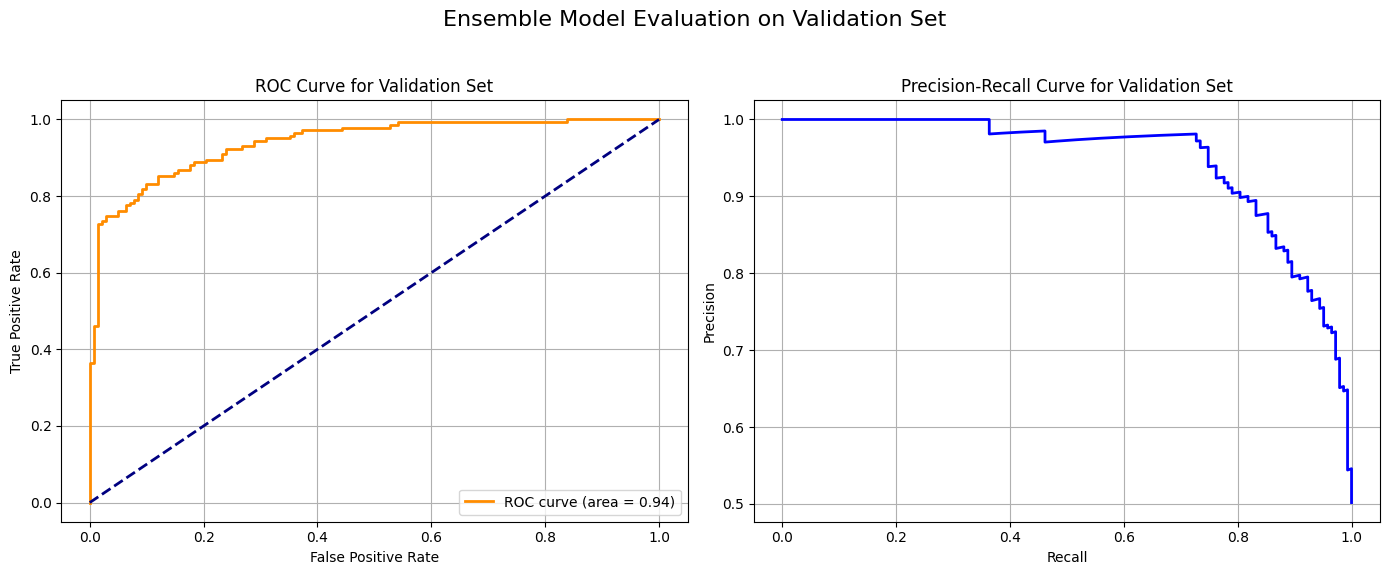

In [12]:
test_video_data = load_videos_with_sequences('/content/ucf-crime-splitted-i3d-features/val')

# Then run the eval:
results = evaluate_split_with_ensemble(
    data_split_name="Validation",
    video_data=test_video_data,
    model_paths=model_paths,
    probablity_threshold=0.90,
    percent_sequences_threshold=0.07
)

4.3 Evaluate on Test Set

Loading anomaly videos: 100%|██████████| 142/142 [00:03<00:00, 36.72video/s]


🔄 Loading models...
✅ 5 models loaded.



Evaluating: 100%|██████████| 285/285 [00:05<00:00, 49.02video/s]



✅ Evaluation Results
→ Accuracy : 0.8772
→ Precision: 0.8905
→ Recall   : 0.8592
→ F1 Score : 0.8746
→ ROC AUC  : 0.9390

📊 Confusion Matrix:
[[128  15]
 [ 20 122]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       143
           1       0.89      0.86      0.87       142

    accuracy                           0.88       285
   macro avg       0.88      0.88      0.88       285
weighted avg       0.88      0.88      0.88       285



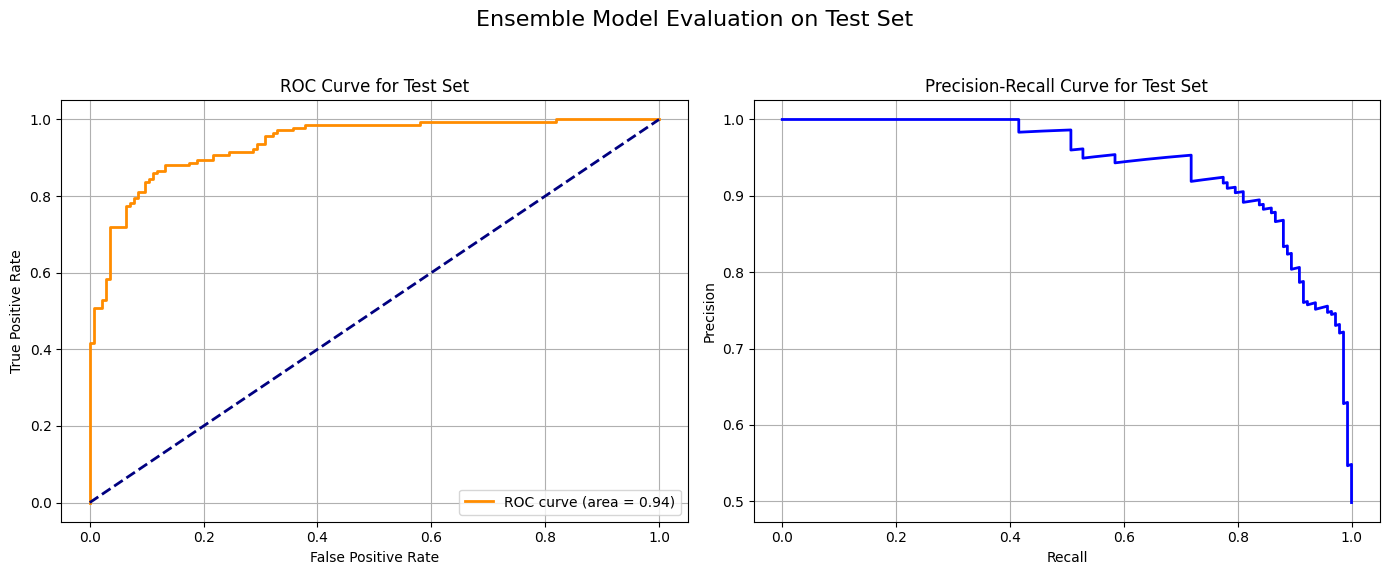

In [13]:
test_video_data = load_videos_with_sequences('/content/ucf-crime-splitted-i3d-features/test')
# Then run the eval:
results = evaluate_split_with_ensemble(
    data_split_name="Test",
    video_data=test_video_data,
    model_paths=model_paths,
    probablity_threshold=0.90,
    percent_sequences_threshold=0.07
)

# 5. Visualization of Predictions

5.1 Function Definitions and Data Loading

In [14]:

# --- CONFIG ---
probability_threshold = 0.90
percent_sequences_threshold = 0.07

# --- Helper function for evaluation ---
def evaluate_video_proportion_details(preds, probability_threshold, percent_sequences_threshold):
    """Classifies a video and returns the prediction details."""
    preds = np.atleast_1d(preds)
    if preds.size == 0:
        return 0, 0.5, 0, 0
    high_conf_count = np.sum(preds >= probability_threshold)
    threshold_count = max(1, int(np.ceil(len(preds) * percent_sequences_threshold)))
    pred = int(high_conf_count >= threshold_count)
    return pred, np.mean(preds), high_conf_count, threshold_count


# --- Core Plotting Function ---
def plot_video_predictions(video, models, probability_threshold, percent_sequences_threshold):
    """Generates a single plot of sequence-level predictions for a given video."""
    video_name = video.get('video_name', 'Unknown Video')
    true_label = 'Anomaly' if video['label'] == 1 else 'Normal'

    all_preds = np.stack([model.predict(video['sequences'], verbose=0).squeeze() for model in models.values()])
    ensemble_preds = np.mean(all_preds, axis=0)

    pred_label_int, _, high_conf_count, required_count = evaluate_video_proportion_details(ensemble_preds, probability_threshold, percent_sequences_threshold)
    pred_label_str = 'Anomaly' if pred_label_int == 1 else 'Normal'

    plt.figure(figsize=(10, 5))
    plt.plot(ensemble_preds, marker='o', linestyle='-', color='b', label='Sequence Probability')
    plt.axhline(y=probability_threshold, color='r', linestyle='--', label=f'Probability Threshold ({probability_threshold:.2f})')
    high_conf_indices = np.where(ensemble_preds >= probability_threshold)[0]
    plt.scatter(high_conf_indices, ensemble_preds[high_conf_indices], color='red', s=100, zorder=5, label=f'Above Threshold ({high_conf_count} seqs)')

    plot_title = f"Video: {video_name} | True: {true_label} | Pred: {pred_label_str}\n"
    plot_title += f"Anomalous Sequences: {high_conf_count} / {len(ensemble_preds)} (Needed: {required_count})"
    plt.title(plot_title, fontsize=12)
    plt.xlabel("Sequence Index")
    plt.ylabel("Anomaly Probability Score")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Load models and data once ---
print("🔄 Loading models and test data...")
models = {name: load_model(path) for name, path in model_paths.items() if os.path.exists(path)}
test_video_data = load_videos_with_sequences('/content/ucf-crime-splitted-i3d-features/test')
print(f"✅ {len(models)} models and {len(test_video_data)} videos loaded.")

# --- Separate normal and anomaly videos ---
normal_videos = [v for v in test_video_data if v['label'] == 0]
anomaly_videos = [v for v in test_video_data if v['label'] == 1]

🔄 Loading models and test data...


Loading anomaly videos: 100%|██████████| 142/142 [00:04<00:00, 32.48video/s]

✅ 5 models and 285 videos loaded.


Plotting a Random Sample of Normal Videos

🎥 Generating plots for a random sample of 5 Normal videos...


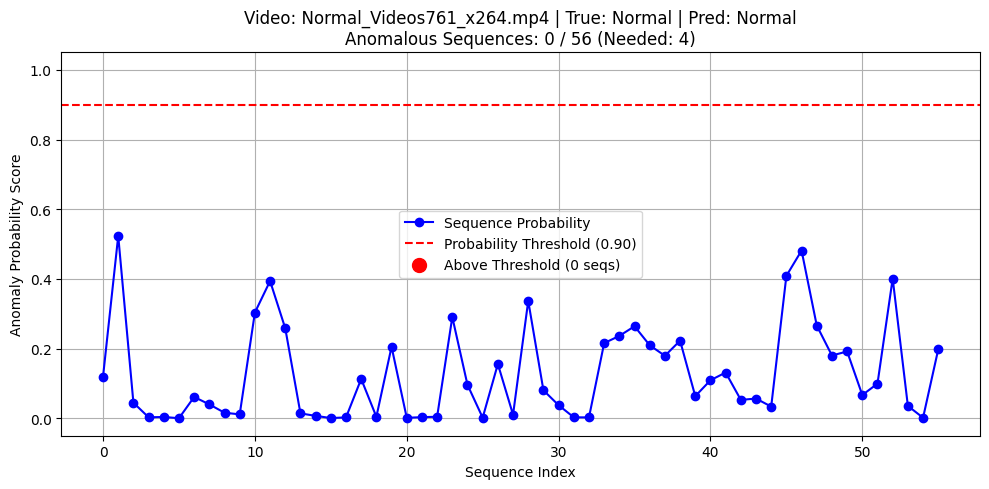

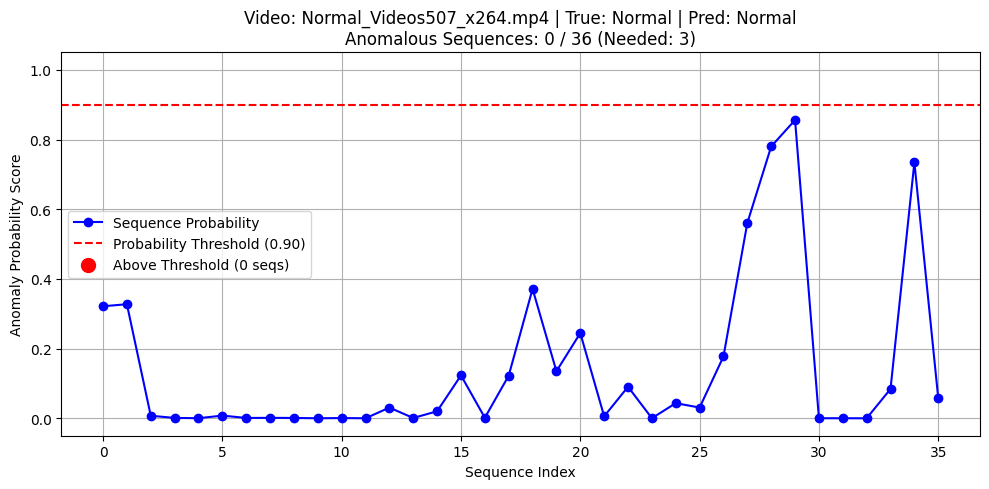

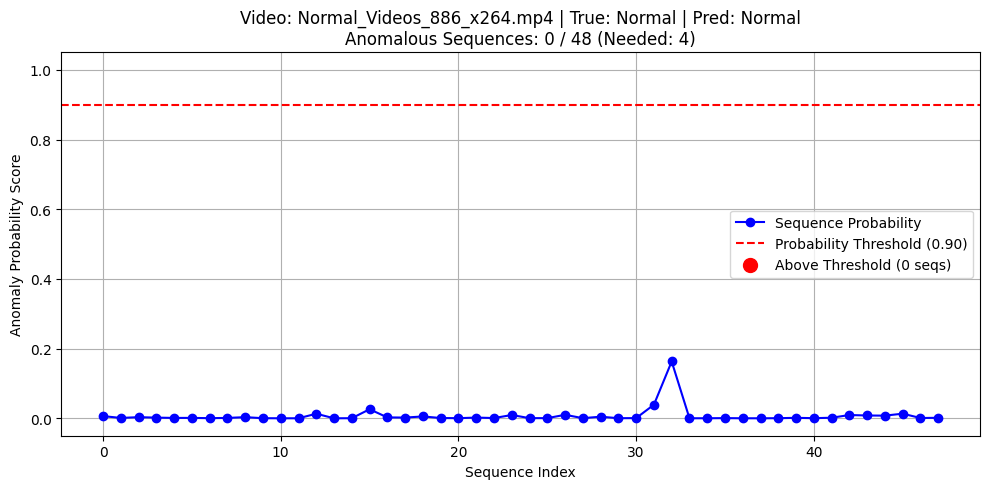

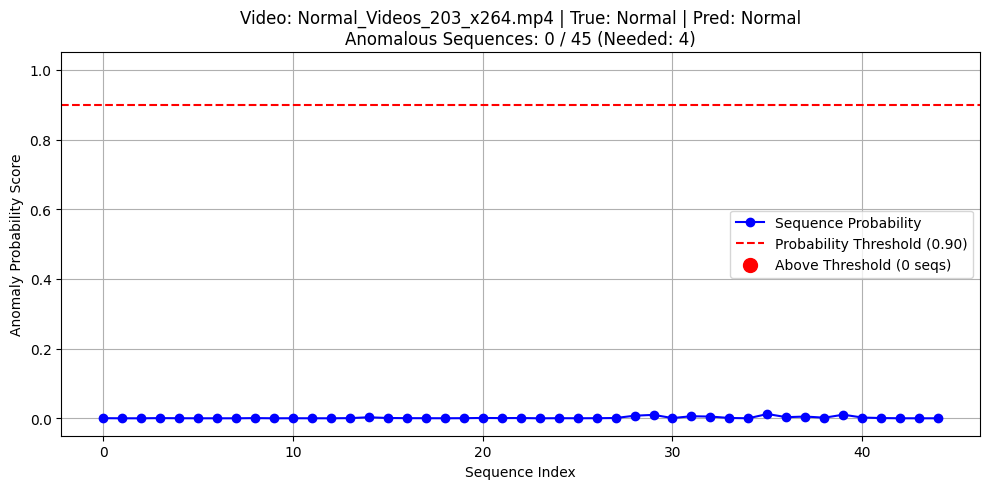

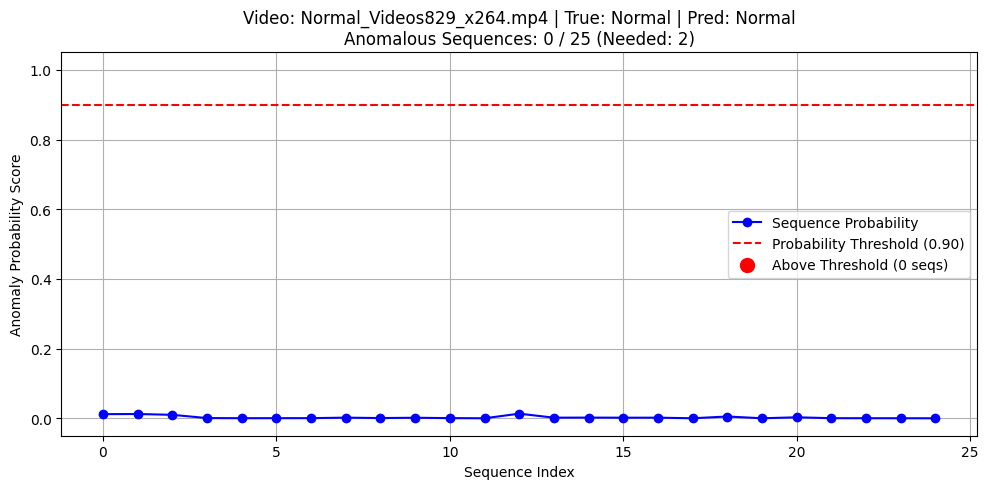

In [17]:
# Select a random sample of normal videos
sample_size = min(5, len(normal_videos))
normal_sample = random.sample(normal_videos, sample_size)

print(f"🎥 Generating plots for a random sample of {sample_size} Normal videos...")
for vid in normal_sample:
    plot_video_predictions(vid, models, probability_threshold, percent_sequences_threshold)

Plotting a Random Sample of Anomaly Videos

🎥 Generating plots for a random sample of 5 Anomaly videos...


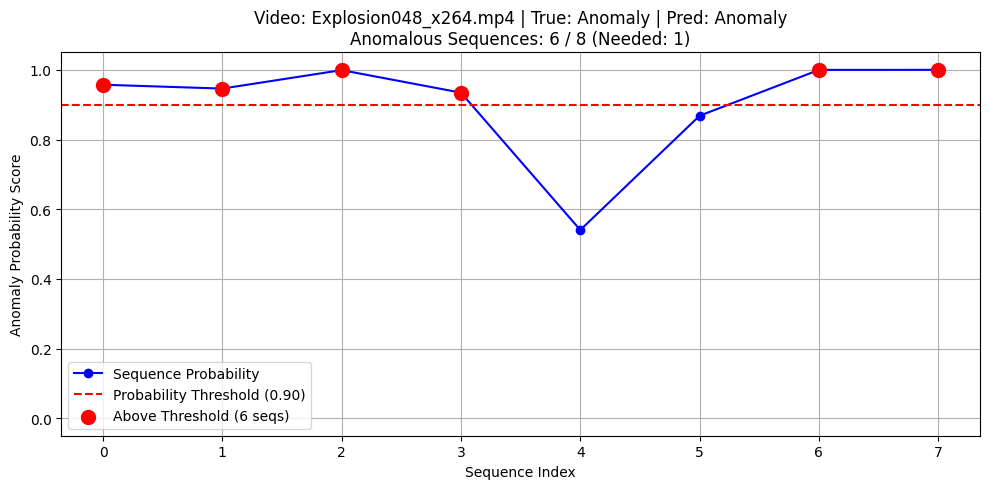

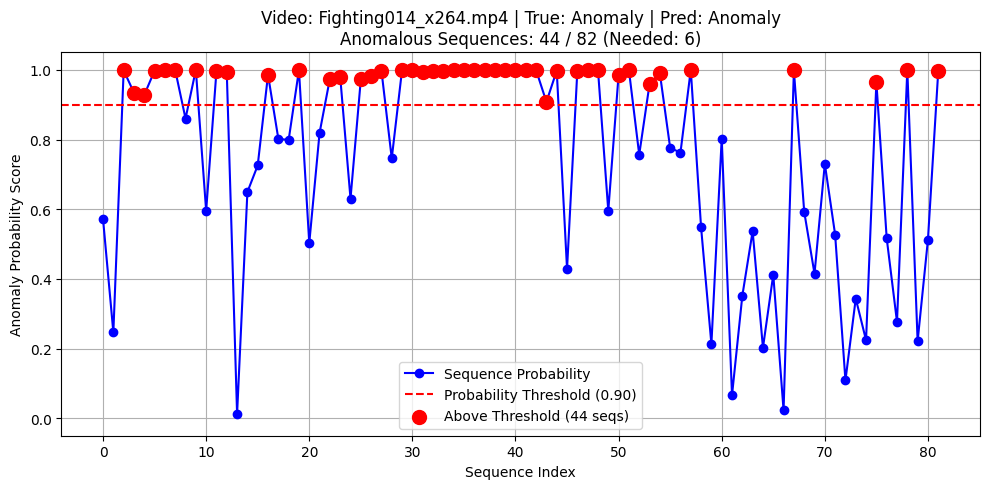

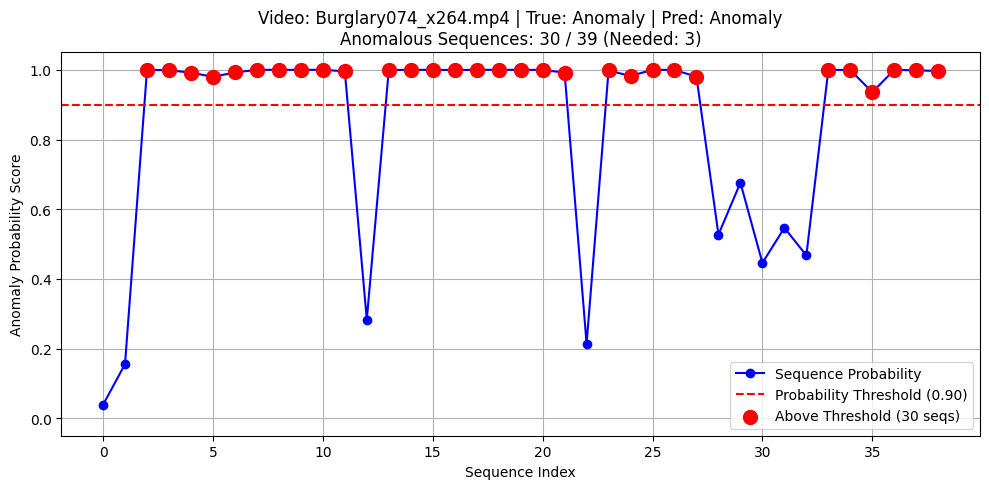

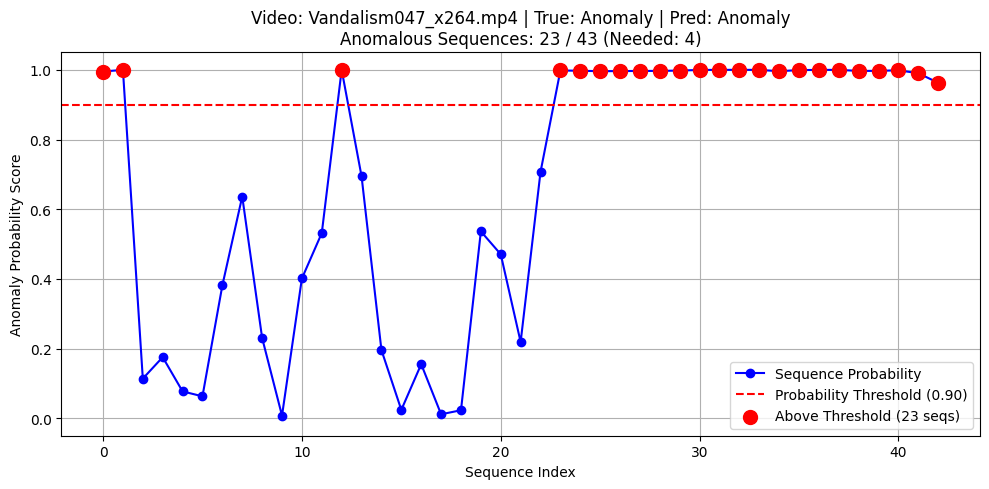

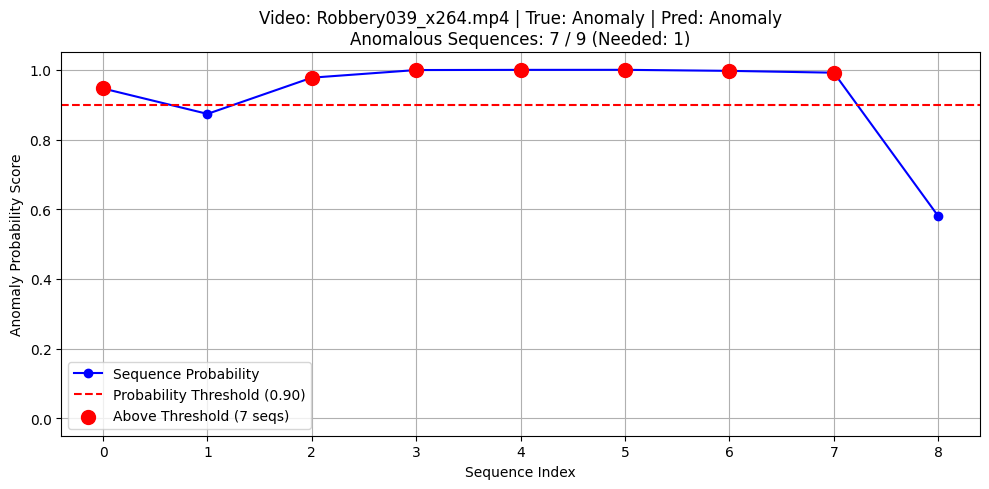

In [18]:
# Select a random sample of anomaly videos
sample_size = min(5, len(anomaly_videos))
anomaly_sample = random.sample(anomaly_videos, sample_size)

print(f"🎥 Generating plots for a random sample of {sample_size} Anomaly videos...")
for vid in anomaly_sample:
    plot_video_predictions(vid, models, probability_threshold, percent_sequences_threshold)